Usando o dispositivo: cuda


/tmp/ipykernel_160772/3094185923.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location=device)


Pesos do modelo extraídos e carregados com sucesso!


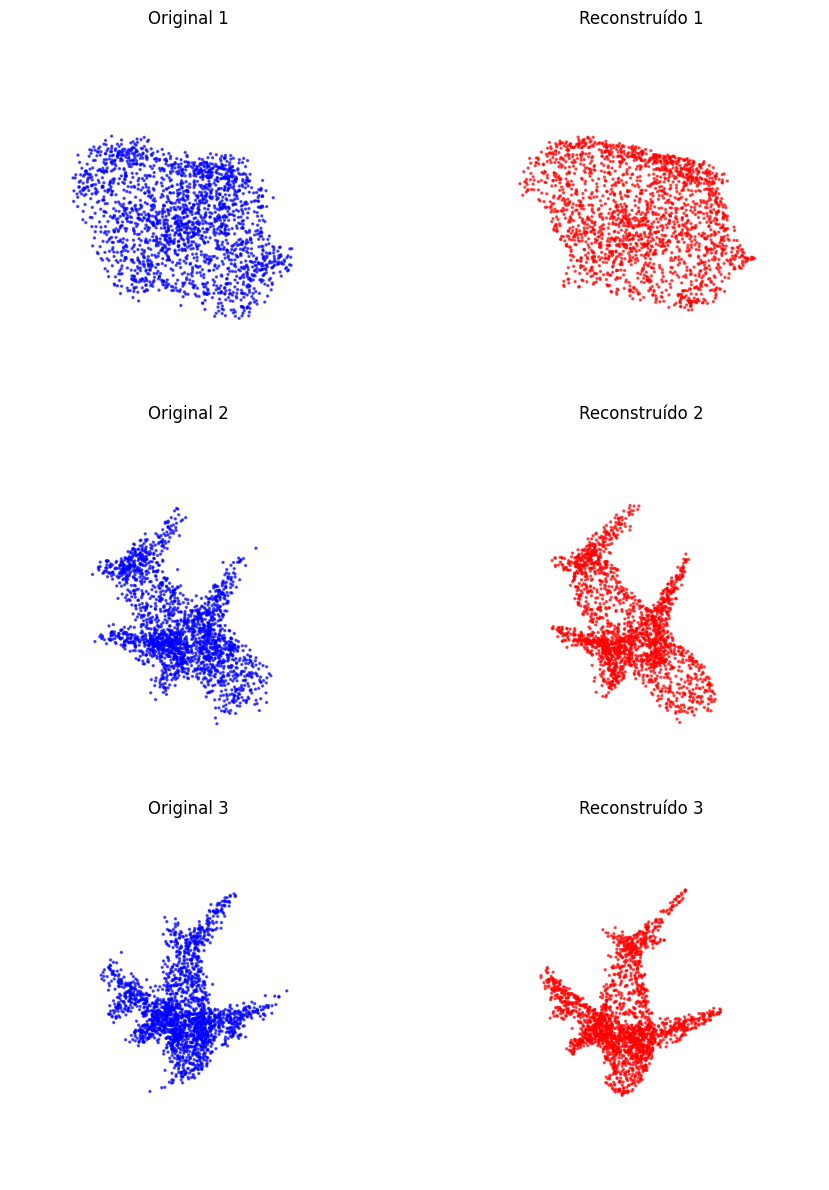

In [16]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Importando suas classes
from src.vae_up import VaeUp
from src.dataset import Ds_point_sampled_already

def plot_side_by_side(original, reconstructed, num_samples=3):
    """
    Plota as nuvens de pontos originais e reconstruídas lado a lado.
    """
    fig = plt.figure(figsize=(10, 4 * num_samples))
    
    for i in range(num_samples):
        # Conversão para numpy para plotagem
        orig = original[i].cpu().numpy()
        recon = reconstructed[i].detach().cpu().numpy()
        
        # Subplot Original (Coluna 1)
        ax_orig = fig.add_subplot(num_samples, 2, 2 * i + 1, projection='3d')
        ax_orig.scatter(orig[:, 0], orig[:, 1], orig[:, 2], c='blue', s=2, alpha=0.6)
        ax_orig.set_title(# Como o modelo está em modo de avaliação (eval), desativamos o cálculo de gradientes
f"Original {i+1}")
        ax_orig.axis('off') # Remove os eixos para focar na geometria
        
        # Subplot Reconstruído (Coluna 2)
        ax_recon = fig.add_subplot(num_samples, 2, 2 * i + 2, projection='3d')
        ax_recon.scatter(recon[:, 0], recon[:, 1], recon[:, 2], c='red', s=2, alpha=0.6)
        ax_recon.set_title(f"Reconstruído {i+1}")
        ax_recon.axis('off')
        
    plt.tight_layout()
    plt.show()

def main():
    # 1. Configurar o dispositivo (GPU se disponível, senão CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Usando o dispositivo: {device}")

    # 2. Inicializar o dataset e o DataLoader
    ds = Ds_point_sampled_already("point_clouds")
    # Carrega uma pequena quantidade para visualização
    dataloader = DataLoader(ds, batch_size=4, shuffle=True) 


    # 3. Inicializar e carregar os pesos do modelo
    vae = VaeUp()
    weights_path = "Best_UP_A_ckpt/best.pt"
    
    if os.path.exists(weights_path):
        checkpoint = torch.load(weights_path, map_location=device)
        
        # Correção aqui: extraindo a chave 'model' do checkpoint
        if isinstance(checkpoint, dict) and "model" in checkpoint:
            vae.load_state_dict(checkpoint["model"])
            print("Pesos do modelo extraídos e carregados com sucesso!")
        elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            vae.load_state_dict(checkpoint["state_dict"])
            print("Pesos do state_dict carregados com sucesso!")
        else:
            vae.load_state_dict(checkpoint)
            print("Pesos carregados com sucesso!")
    else:
        print(f"Erro: O arquivo de pesos em '{weights_path}' não foi encontrado.")
        return
    

    vae.to(device)
    vae.eval() # Modo de inferência

    # 4. Pegar um lote (batch) de dados
    with torch.no_grad():
        for batch in dataloader:
            # Se o seu dataset retorna uma tupla (ex: dado, label), pegamos apenas o dado
            if isinstance(batch, (list, tuple)):
                points = batch[0]
            else:
                points = batch
                
            points = points.to(device)
            
            # 5. Passar pelo VAE
            # Nota: Ajuste a linha abaixo caso o método de saída do seu VaeUp 
            # retorne múltiplos valores (ex: reconstrução, mu, logvar)
            outputs = vae(points)
            
            if isinstance(outputs, (list, tuple)):
                reconstructed = outputs[0] # Geralmente o primeiro elemento é a reconstrução
            else:
                reconstructed = outputs
                
            # 6. Plotar os resultados lado a lado
            plot_side_by_side(points, reconstructed, num_samples=3)
            break # Paramos no primeiro batch para mostrar apenas os exemplos configurados

if __name__ == "__main__":
    main()

In [39]:
import os
import torch
import open3d as o3d
from torch.utils.data import DataLoader

# Importando suas classes
from src.vae_up import VaeUp
from src.dataset import Ds_point_sampled_already
from src.Vae import normalize_pc

def create_o3d_cloud(points_np, color):
    """
    Cria uma nuvem de pontos do Open3D e atribui uma cor uniforme.
    """
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_np[:, :3]) # Garante apenas XYZ
    pcd.paint_uniform_color(color)
    return pcd

def visualize_single_interpolation(clouds, num_steps, window_title):
    """
    Abre uma janela Open3D dedicada para uma única linha de interpolação,
    aplicando as cores Azul (A), Vermelho (B) e Cinza (Intermediários).
    """
    geometries = []
    offset_x = 1.5  # Distância horizontal entre os modelos
    
    for col_idx in range(num_steps):
        cloud_np = clouds[col_idx].cpu().numpy()
        
        # Define a cor com base na posição
        if col_idx == 0:
            color = [0.0, 0.0, 1.0]      # Dado A: Azul Puro
        elif col_idx == num_steps - 1:
            color = [1.0, 0.0, 0.0]      # Dado B: Vermelho Puro
        else:
            color = [0.6, 0.6, 0.6]      # Entre eles: Cinza
            
        pcd = create_o3d_cloud(cloud_np, color)
        
        # Posiciona lado a lado no eixo X
        pcd.translate((col_idx * offset_x, 0, 0))
        geometries.append(pcd)

    print(f"\n[Open3D] Abrindo: {window_title}")
    print(" -> AZUL: Dado A | CINZA: Intermediários | VERMELHO: Dado B")
    print(" -> Feche esta janela para abrir a próxima interpolação.")
    
    o3d.visualization.draw_geometries(
        geometries,
        window_name=window_title,
        width=1280,
        height=720
    )

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Usando o dispositivo: {device}")

    # Inicializar o dataset e o DataLoader (pegando 2 exemplos distintos)
    ds = Ds_point_sampled_already("point_clouds")
    dataloader = DataLoader(ds, batch_size=2, shuffle=True) 

    # Inicializar e carregar pesos do modelo
    vae = VaeUp()
    weights_path = "Best_UP_A_ckpt/best.pt"
    
    if os.path.exists(weights_path):
        checkpoint = torch.load(weights_path, map_location=device)
        if isinstance(checkpoint, dict) and "model" in checkpoint:
            vae.load_state_dict(checkpoint["model"])
        else:
            vae.load_state_dict(checkpoint)
        print("Pesos carregados com sucesso!")
    else:
        print(f"Erro: '{weights_path}' não encontrado.")
        return
    
    vae.to(device)
    vae.eval() 

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                points = batch[0]
            else:
                points = batch
                
            if points.shape[0] < 2:
                print("O batch precisa ter tamanho >= 2.")
                return
                
            points = normalize_pc(points).to(device)
            
            cloud_A = points[0].unsqueeze(0) 
            cloud_B = points[1].unsqueeze(0) 
            
            # --- PASSO 1: Extrair os Latentes Originais ---
            mu_g_A, _ = vae.global_encoder(cloud_A)
            mu_l_A, _ = vae.local_encoder(cloud_A, mu_g_A)
            
            mu_g_B, _ = vae.global_encoder(cloud_B)
            mu_l_B, _ = vae.local_encoder(cloud_B, mu_g_B)
            
            # --- PASSO 2: Configurar os passos de Interpolação ---
            num_steps = 5
            interp_global_clouds = []
            interp_local_clouds = []
            interp_both_clouds = []
            
            for i in range(num_steps):
                alpha = i / (num_steps - 1)
                
                # 1. INTERPOLAÇÃO APENAS GLOBAL
                z_g_only = (1 - alpha) * mu_g_A + alpha * mu_g_B
                out_global = vae.decoder(mu_l_A, z_g_only)
                interp_global_clouds.append(out_global.squeeze(0))
                
                # 2. INTERPOLAÇÃO APENAS LOCAL
                z_l_only = (1 - alpha) * mu_l_A + alpha * mu_l_B
                out_local = vae.decoder(z_l_only, mu_g_A)
                interp_local_clouds.append(out_local.squeeze(0))
                
                # 3. INTERPOLAÇÃO DE AMBOS
                z_g_both = (1 - alpha) * mu_g_A + alpha * mu_g_B
                z_l_both = (1 - alpha) * mu_l_A + alpha * mu_l_B
                out_both = vae.decoder(z_l_both, z_g_both)
                interp_both_clouds.append(out_both.squeeze(0))
                
            # --- PASSO 3: Abrir uma janela por vez ---
            visualize_single_interpolation(interp_global_clouds, num_steps, "1. Interpolação APENAS GLOBAL (Estilo)")
            visualize_single_interpolation(interp_local_clouds, num_steps, "2. Interpolação APENAS LOCAL (Posições)")
            visualize_single_interpolation(interp_both_clouds, num_steps, "3. Interpolação AMBOS (Global + Local)")
            break 

if __name__ == "__main__":
    main()

Usando o dispositivo: cuda


/tmp/ipykernel_160772/844755087.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location=device)


Pesos carregados com sucesso!

[Open3D] Abrindo: 1. Interpolação APENAS GLOBAL (Estilo)
 -> AZUL: Dado A | CINZA: Intermediários | VERMELHO: Dado B
 -> Feche esta janela para abrir a próxima interpolação.

[Open3D] Abrindo: 2. Interpolação APENAS LOCAL (Posições)
 -> AZUL: Dado A | CINZA: Intermediários | VERMELHO: Dado B
 -> Feche esta janela para abrir a próxima interpolação.

[Open3D] Abrindo: 3. Interpolação AMBOS (Global + Local)
 -> AZUL: Dado A | CINZA: Intermediários | VERMELHO: Dado B
 -> Feche esta janela para abrir a próxima interpolação.


In [38]:
import os
import torch
import numpy as np
import open3d as o3d
from torch.utils.data import DataLoader

# Importando suas classes
from src.vae_up import VaeUp
from src.dataset import Ds_point_sampled_already
from src.Vae import normalize_pc

def create_o3d_cloud(points_np, color):
    """
    Cria uma nuvem de pontos do Open3D e atribui uma cor uniforme.
    """
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_np[:, :3]) # Garante apenas XYZ
    pcd.paint_uniform_color(color)
    return pcd

def visualize_with_open3d(original, reconstruction, neighbors):
    """
    Coloca todas as nuvens de pontos lado a lado em uma única janela interativa do Open3D.
    """
    geometries = []
    
    # Configuração do espaçamento horizontal (eixo X) para elas não se sobreporem
    offset_x = 1.5 
    current_offset = 0.0

    # 1. Original (Azul)
    pcd_orig = create_o3d_cloud(original.cpu().numpy(), color=[0.1, 0.3, 0.9])
    geometries.append(pcd_orig)
    current_offset += offset_x

    # 2. Reconstrução Base (Verde)
    pcd_recon = create_o3d_cloud(reconstruction.cpu().numpy(), color=[0.1, 0.8, 0.2])
    pcd_recon.translate((current_offset, 0, 0)) # Move para o lado
    geometries.append(pcd_recon)
    current_offset += offset_x

    # 3. Vizinhos Latentes (Tons de Roxo/Rosa)
    for i, neighbor_cloud in enumerate(neighbors):
        pcd_neigh = create_o3d_cloud(neighbor_cloud.cpu().numpy(), color=[0.6, 0.1, 0.7])
        pcd_neigh.translate((current_offset, 0, 0)) # Move mais para o lado
        geometries.append(pcd_neigh)
        current_offset += offset_x

    # Criar uma linha de referência (chão) ou eixos para ajudar na orientação (opcional)
    # geometries.append(o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.3, origin=[0, 0, 0]))

    print("\n[Open3D] Abrindo janela interativa...")
    print(" -> Use o MOUSE (Clique esquerdo) para rotacionar.")
    print(" -> Use o MOUSE (Clique direito ou Scroll) para dar zoom.")
    print(" -> Segure SHIFT + Clique esquerdo para mover a câmera (PAN).")
    print(" -> Feche a janela para encerrar o script.")
    
    # Abre a janela de renderização interativa
    o3d.visualization.draw_geometries(
        geometries, 
        window_name="VAE Latent Neighborhood - Open3D",
        width=1280,
        height=720
    )

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Inicializar o dataset
    ds = Ds_point_sampled_already("point_clouds")
    dataloader = DataLoader(ds, batch_size=1, shuffle=True) 

    # Inicializar e carregar pesos do modelo
    vae = VaeUp()
    weights_path = "Best_UP_A_ckpt/best.pt"
    
    if os.path.exists(weights_path):
        checkpoint = torch.load(weights_path, map_location=device)
        if isinstance(checkpoint, dict) and "model" in checkpoint:
            vae.load_state_dict(checkpoint["model"])
        else:
            vae.load_state_dict(checkpoint)
    else:
        print(f"Erro: '{weights_path}' não encontrado.")
        return
    
    vae.to(device)
    vae.eval() 

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                points = batch[0]
            else:
                points = batch
                
            points = normalize_pc(points).to(device)
            cloud_target = points[0].unsqueeze(0)
            
            # Codificar latentes
            mu_g, _ = vae.global_encoder(cloud_target)
            mu_l, _ = vae.local_encoder(cloud_target, mu_g)
            
            # Reconstrução
            recon_base = vae.decoder(mu_l, mu_g).squeeze(0)
            
            # Gerar vizinhos latentes
            noise_level = 1
            num_neighbors = 3
            neighbor_clouds = []
            
            for _ in range(num_neighbors):
                perturbed_g = mu_g + torch.randn_like(mu_g) * noise_level
                perturbed_l = mu_l + torch.randn_like(mu_l) * noise_level
                recon_neighbor = vae.decoder(perturbed_l, perturbed_g)
                neighbor_clouds.append(recon_neighbor.squeeze(0))
                
            # Chamar a visualização fluida com Open3D
            visualize_with_open3d(cloud_target.squeeze(0), recon_base, neighbor_clouds)
            break 

if __name__ == "__main__":
    main()

/tmp/ipykernel_160772/1781413522.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location=device)



[Open3D] Abrindo janela interativa...
 -> Use o MOUSE (Clique esquerdo) para rotacionar.
 -> Use o MOUSE (Clique direito ou Scroll) para dar zoom.
 -> Segure SHIFT + Clique esquerdo para mover a câmera (PAN).
 -> Feche a janela para encerrar o script.
